# Sprint 2 - Limpeza, Tratamento, Split Temporal e EDA
Este notebook executa os Tópicos 1 e 2 detalhados no `Sprint2_TrilhaC.md`:
1. **Limpeza e Inspeção:** Verifica valores nulos, duplicatas e aplica regras de domínio (mantendo a pasta raw intocada).
2. **Split Temporal:** Divide os dados de 2015 a 2022 para Treino e 2023 a 2025 para Teste.
3. **Análise Exploratória (EDA):** Realiza os gráficos requisitados APENAS sobre a base de Treino.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Garantir que a pasta interim existe
os.makedirs('../data/interim', exist_ok=True)

# Carregando os dados brutos da Sprint 1
df_raw = pd.read_csv('../data/raw/integrado.csv')
display(df_raw.head())

,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
0,2015,400.0,400.0,960.0,2400.0,1292.21,22.402685,39.91,9.01,74.525507,0.589973
1,2016,500.0,500.0,1200.0,2400.0,1243.65,21.431339,37.37,3.24,76.412322,0.640492
2,2017,500.0,500.0,1200.0,2400.0,1252.76,21.700493,37.61,5.39,73.824438,0.601863
3,2018,500.0,500.0,1200.0,2400.0,1126.40,22.172630,36.06,5.82,72.083233,0.569863
4,2019,1200.0,1200.0,3000.0,2500.0,1056.55,22.776274,39.10,4.43,70.784301,0.567205


## 1.1 Inspeção e Limpeza

In [2]:
print("=== Estatística Descritiva (Raw) ===")
display(df_raw.describe())

print("\n=== Contagem de Nulos ===")
print(df_raw.isnull().sum())

print("\n=== Linhas Duplicadas ===")
print(df_raw.duplicated().sum())

=== Estatística Descritiva (Raw) ===


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,2020.000000,1036.363636,1036.363636,2585.454545,2463.636364,1052.958182,22.436490,38.920000,4.854545,69.685810,0.567360
std,3.316625,471.747236,471.747236,1278.282939,180.403588,203.291181,0.695130,1.974644,1.976559,4.998708,0.037111
min,2015.000000,400.000000,400.000000,960.000000,2400.000000,633.730000,21.431339,36.060000,1.770000,61.983534,0.517178
25%,2017.500000,500.000000,500.000000,1200.000000,2400.000000,945.390000,21.950658,37.490000,3.750000,65.941383,0.539713
50%,2020.000000,1200.000000,1200.000000,2880.000000,2400.000000,1107.200000,22.494877,39.100000,4.590000,70.784301,0.567205
75%,2022.500000,1350.000000,1350.000000,3300.000000,2400.000000,1206.420000,22.686014,40.125000,5.955000,72.953836,0.590055
max,2025.000000,1600.000000,1600.000000,4800.000000,3000.000000,1292.210000,23.897541,42.030000,9.010000,76.412322,0.640492



=== Contagem de Nulos ===
ano                       0
area_plantada_ha          0
area_colhida_ha           0
quantidade_produzida_t    0
rendimento_kg_ha          0
PRECTOTCORR               0
T2M                       0
T2M_MAX                   0
T2M_MIN                   0
RH2M                      0
GWETROOT                  0
dtype: int64

=== Linhas Duplicadas ===
0


**Diagnóstico do Grupo:** Conforme observado acima, nossa base integrada veio limpa da Etapa de Coleta (sem nulos e sem duplicatas), pois o tratamento primário de sentinelas (-999) já foi mapeado no momento da integração do IBGE e NASA na Sprint 1.

In [3]:
df_limpo = df_raw.copy()

# Salvar em data/interim (A Regra Sagrada da Prof!)
df_limpo.to_csv('../data/interim/limpo.csv', index=False)
print("Dados limpos salvos em: ../data/interim/limpo.csv")

Dados limpos salvos em: ../data/interim/limpo.csv


## 2. Divisão entre Treino e Teste (Split Temporal)
Para evitar *Data Leakage* temporal, vamos separar:
- **Treino:** 2015 a 2022
- **Teste:** 2023 a 2025

In [4]:
df_treino = df_limpo[df_limpo['ano'] <= 2022].copy()
df_teste = df_limpo[df_limpo['ano'] >= 2023].copy()

print(f"Linhas no Treino: {df_treino.shape[0]} (Anos: {df_treino['ano'].min()} a {df_treino['ano'].max()})")
print(f"Linhas no Teste: {df_teste.shape[0]} (Anos: {df_teste['ano'].min()} a {df_teste['ano'].max()})")

Linhas no Treino: 8 (Anos: 2015 a 2022)
Linhas no Teste: 3 (Anos: 2023 a 2025)


## 4. Análise Exploratória de Dados (EDA) - Apenas no Treino!

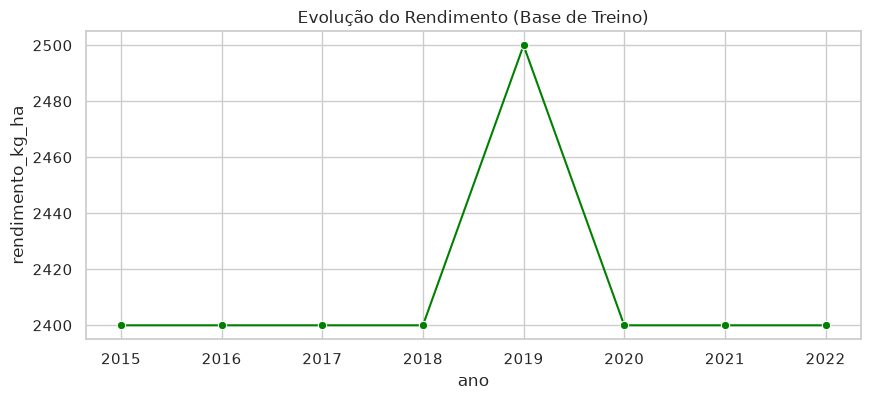

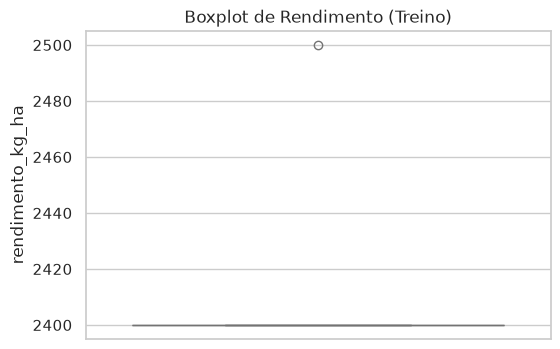

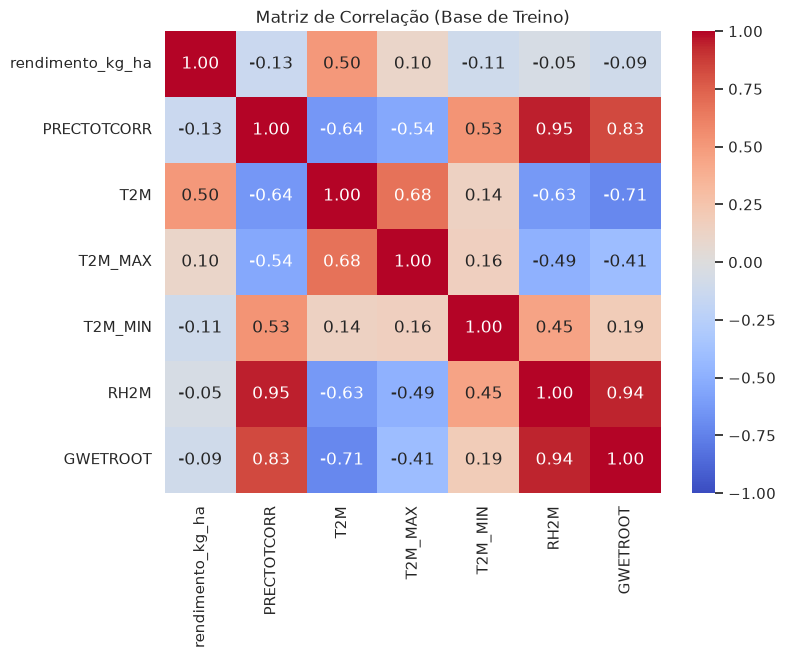

In [5]:
sns.set_theme(style="whitegrid")

# 1. Evolução da Produtividade (Treino)
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_treino, x='ano', y='rendimento_kg_ha', marker='o', color='green')
plt.title('Evolução do Rendimento (Base de Treino)')
plt.xticks(df_treino['ano'])
plt.show()

# 2. Boxplot para encontrar Outliers
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_treino['rendimento_kg_ha'], color='lightgreen')
plt.title('Boxplot de Rendimento (Treino)')
plt.show()

# 3. Matriz de Correlação das Features Climáticas x Rendimento
colunas_corr = ['rendimento_kg_ha', 'PRECTOTCORR', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'GWETROOT']
plt.figure(figsize=(8, 6))
sns.heatmap(df_treino[colunas_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação (Base de Treino)')
plt.show()